# Week 1 solution — Describing a dataset you have not seen

In [1]:
import math9102 as m9
import numpy as np
import pandas as pd

m9.use_house_style()

msleep = m9.load_msleep()

---

## Question 1 — Get oriented

In [2]:
print(msleep.shape)
msleep.dtypes

(83, 11)


name                str
genus               str
vore                str
order               str
conservation        str
sleep_total     float64
sleep_rem       float64
sleep_cycle     float64
awake           float64
brainwt         float64
bodywt          float64
dtype: object

In [3]:
msleep.head()

,name,genus,vore,order,conservation,sleep_total,sleep_rem,sleep_cycle,awake,brainwt,bodywt
0,Cheetah,Acinonyx,carni,Carnivora,lc,12.1,NaN,NaN,11.9,NaN,50.000
1,Owl monkey,Aotus,omni,Primates,NaN,17.0,1.8,NaN,7.0,0.01550,0.480
2,Mountain beaver,Aplodontia,herbi,Rodentia,nt,14.4,2.4,NaN,9.6,NaN,1.350
3,Greater short-tailed shrew,Blarina,omni,Soricomorpha,lc,14.9,2.3,0.133333,9.1,0.00029,0.019
4,Cow,Bos,herbi,Artiodactyla,domesticated,4.0,0.7,0.666667,20.0,0.42300,600.000


**A row is one mammal species**, not one animal. That matters: these are not 83
observations of individuals drawn from a population of mammals in any sampling
sense. They are 83 species for which somebody has published sleep measurements,
which is a convenience sample of the species that are easy to study.

---

## Question 2 — Classify the variables

| Variable | Level | Why |
|---|---|---|
| `name` | nominal (an identifier) | a label; every value is unique, so it identifies rather than classifies |
| `genus` | nominal | categories with no order |
| `vore` | nominal | carnivore / herbivore / insectivore / omnivore — no order |
| `order` | nominal | taxonomic categories, no order despite the name |
| `conservation` | **ordinal, but see below** | least concern → near threatened → vulnerable → endangered → critically endangered is a genuine ranking — except that one of the categories is not on that ladder at all |
| `sleep_total` | ratio | hours; zero means no sleep, and twice as many hours is twice as long |
| `sleep_rem` | ratio | as above |
| `sleep_cycle` | ratio | as above |
| `awake` | ratio | as above |
| `brainwt` | ratio | kilograms, true zero |
| `bodywt` | ratio | kilograms, true zero |

**The two worth arguing about.**

`conservation` is the interesting one, and it does not have a clean answer.

In [4]:
sorted(msleep.conservation.dropna().unique())

['cd', 'domesticated', 'en', 'lc', 'nt', 'vu']

Five of those codes are IUCN risk levels and *are* ordered: least concern, near
threatened, vulnerable, endangered, critically endangered. The sixth is
`domesticated`, which is not a rung on that ladder — it is a different kind of
statement about the animal, and there is no position on the risk scale where it
belongs.

So the variable **as coded** is not ordinal. It is a risk ranking with a
non-ranking category mixed into it. You have three defensible options, and the
exercise is to choose one and say so: treat the whole thing as nominal; separate
`domesticated` out into its own indicator and treat the remainder as ordinal; or
exclude domesticated species from any analysis that uses the ranking. What you
may not do is quietly sort the codes alphabetically and call the result an
order.

This is the week's lesson in miniature. **The level of measurement is not a
property the file can tell you.** You have to look at the actual category values
and decide.

`order` is the simpler trap. The word suggests ordering; taxonomic order is a
nominal classification.

**Which would be meaningless to average?** `name`, `genus`, `vore`, `order` and
`conservation`. For the first four this is obvious. For `conservation` it is
less obvious and more important: you could assign the codes numbers 1 to 6 and
compute a mean, the software would not object, and the answer would depend
entirely on the arbitrary spacing you chose and on where you decided to slot
`domesticated` in.

---

## Question 3 — Describe the categorical variables

In [5]:
m9.frequency(msleep, "vore")

,count,percent,valid_percent
vore,,,
carni,19,22.89,25.00
herbi,32,38.55,42.11
insecti,5,6.02,6.58
omni,20,24.10,26.32
NaN,7,8.43,NaN


Note the two percentage columns. `percent` is out of all animals; `valid_percent`
is out of those with a recorded value. **They are not the same number and they
answer different questions.**

In [6]:
m9.frequency(msleep, "conservation")

,count,percent,valid_percent
conservation,,,
cd,2,2.41,3.70
domesticated,10,12.05,18.52
en,4,4.82,7.41
lc,27,32.53,50.00
nt,4,4.82,7.41
vu,7,8.43,12.96
NaN,29,34.94,NaN


In [7]:
unknown = msleep.conservation.isna().sum()
print(f"animals with no conservation status: {unknown} of {len(msleep)}"
      f" ({unknown / len(msleep):.1%})")

animals with no conservation status: 29 of 83 (34.9%)


Roughly a third of the animals have no recorded conservation status. Any
statement about conservation in this dataset is therefore a statement about the
two thirds that have one — and those are unlikely to be a random two thirds,
since well-studied species are more likely to have been assessed. Say so, every
time.

In [8]:
m9.crosstab(msleep, "vore", "conservation")

conservation,cd,domesticated,en,lc,nt,vu
vore,,,,,,
carni,1,2,1,5,1,4
herbi,1,7,2,10,3,3
insecti,0,0,1,2,0,0
omni,0,1,0,8,0,0


In [9]:
m9.crosstab(msleep, "vore", "conservation", normalize="index")

conservation,cd,domesticated,en,lc,nt,vu
vore,,,,,,
carni,7.1,14.3,7.1,35.7,7.1,28.6
herbi,3.8,26.9,7.7,38.5,11.5,11.5
insecti,0.0,0.0,33.3,66.7,0.0,0.0
omni,0.0,11.1,0.0,88.9,0.0,0.0


**What the row percentages are a percentage of:** each row sums to 100, so each
cell is the percentage *of animals with that diet* that have that conservation
status. A column-wise version would instead give, of the animals at each
conservation status, the percentage with each diet — a different question, and
the one you would ask if conservation status were the grouping you cared about.

With cells this small, neither table supports much. Report the counts alongside.

---

## Question 4 — Describe two continuous variables

In [10]:
for col in ("sleep_total", "bodywt"):
    x = msleep[col].dropna()
    print(f"{col}")
    print(f"  mean   = {x.mean():.2f}")
    print(f"  median = {x.median():.2f}")
    print(f"  mode   = {x.mode().iloc[0]:.2f}")

sleep_total
  mean   = 10.43
  median = 10.10
  mode   = 12.50
bodywt
  mean   = 166.14
  median = 1.67
  mode   = 1.10


In [11]:
for col in ("sleep_total", "bodywt"):
    x = msleep[col].dropna()
    print(f"{col}")
    print(f"  range = {x.max() - x.min():.2f}")
    print(f"  IQR   = {x.quantile(.75) - x.quantile(.25):.2f}")
    print(f"  SD    = {x.std(ddof=1):.2f}")

sleep_total
  range = 18.00
  IQR   = 5.90
  SD    = 4.45
bodywt
  range = 6653.99
  IQR   = 41.58
  SD    = 786.84


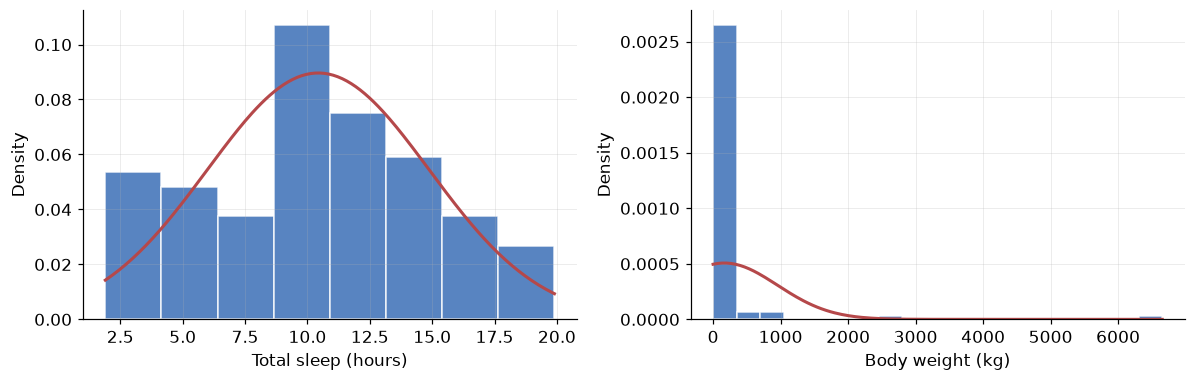

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
m9.histogram_with_normal(msleep.sleep_total.dropna(), xlabel="Total sleep (hours)", ax=axes[0])
m9.histogram_with_normal(msleep.bodywt.dropna(), xlabel="Body weight (kg)", ax=axes[1])
fig.tight_layout();

In [13]:
m9.describe(msleep, ["sleep_total", "bodywt"])

,n,missing,mean,sd,se,median,iqr,min,max,skew,kurtosis
sleep_total,83,0,10.434,4.45,0.488,10.10,5.900,1.900,19.9,0.054,-0.616
bodywt,83,0,166.136,786.84,86.367,1.67,41.576,0.005,6654.0,7.364,58.656


**`sleep_total`.** Roughly symmetric, with mean and median close together and a
modest spread. Report the **mean and standard deviation**; they describe it
fairly.

**`bodywt`.** Extremely right-skewed — most mammals are small and a few weigh
more than a tonne. The mean sits far above the median and above almost every
animal in the dataset. Report the **median and IQR**, and say that the
distribution is skewed rather than leaving the reader to assume it is not.

In [14]:
above = (msleep.bodywt < msleep.bodywt.mean()).mean()
print(f"share of species lighter than the mean body weight: {above:.1%}")

share of species lighter than the mean body weight: 89.2%


That single line is the argument. A "typical value" that all but a handful of
cases fall below is not describing anything typical.

---

## Question 5 — Count the cost of missingness

In [15]:
a = m9.missingness(msleep, ["sleep_total", "vore"])
print(a.attrs["summary"])
a

Listwise deletion across these 2 column(s) keeps 76 of 83 rows (loses 7, 8.4%).


,column,missing,percent
0,vore,7,8.43
1,sleep_total,0,0.00


In [16]:
b = m9.missingness(msleep, ["sleep_cycle", "brainwt", "vore"])
print(b.attrs["summary"])
b

Listwise deletion across these 3 column(s) keeps 29 of 83 rows (loses 54, 65.1%).


,column,missing,percent
0,sleep_cycle,51,61.45
1,brainwt,27,32.53
2,vore,7,8.43


In [17]:
everything = m9.missingness(msleep)
print(everything.attrs["summary"])
everything

Listwise deletion across these 11 column(s) keeps 20 of 83 rows (loses 63, 75.9%).


,column,missing,percent
0,sleep_cycle,51,61.45
1,conservation,29,34.94
2,brainwt,27,32.53
3,sleep_rem,22,26.51
4,vore,7,8.43
5,genus,0,0.00
6,name,0,0.00
7,sleep_total,0,0.00
8,order,0,0.00
9,awake,0,0.00


The same dataset costs you almost nothing or almost everything, depending
entirely on which columns you name. `sleep_cycle` is the expensive one: it is
missing for more than half the species on its own.

Dropping incomplete rows across the whole dataset before choosing your variables
would leave you with a small fraction of the data, most of it lost to a variable
you may never use. **Choose the variables, then count the cost.**

---

## Question 6 — Describe a group difference, without testing it

In [18]:
m9.describe_by(msleep, "sleep_total", "vore")

,n,missing,mean,sd,se,median,iqr,min,max,skew,kurtosis
vore,,,,,,,,,,,
carni,19.0,0.0,10.379,4.669,1.071,10.4,6.750,2.7,19.4,0.117,-0.651
herbi,32.0,0.0,9.509,4.879,0.862,10.3,9.925,1.9,16.6,-0.159,-1.597
insecti,5.0,0.0,14.940,5.921,2.648,18.1,11.100,8.4,19.9,-0.548,-3.256
omni,20.0,0.0,10.925,2.949,0.659,9.9,1.825,8.0,18.0,1.499,1.039


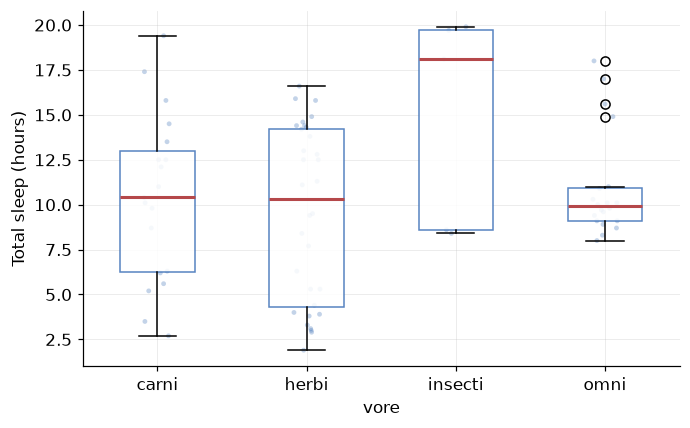

In [19]:
m9.grouped_box(msleep.dropna(subset=["vore"]), "sleep_total", "vore",
               ylabel="Total sleep (hours)");

**Three sentences.**

> Insectivores sleep considerably longer on average than the other three diet
> groups, and herbivores sleep the least; carnivores and omnivores sit close
> together in between. The groups overlap heavily, and the spread within each
> diet is wide compared with the distances between their averages. There are
> only five insectivores in the dataset, so that group's average rests on very
> few species and should not be read as a reliable estimate.

Note what the third sentence does. The group sizes are part of the description,
not a footnote — a mean of five cases and a mean of thirty are not comparable
pieces of evidence, however similar they look side by side in a table.

---

## Question 7 — Judgement

> "We analysed a database of mammals. The average mammal sleeps 10.4 hours a
> night and weighs 166 kg, so the typical mammal is a large, sleepy animal."

**Three problems.**

1. **The mean body weight describes almost no animal in the dataset.** The
   distribution is dominated by a few very heavy species, and the great majority
   of species fall below the mean. "Typical" is precisely the wrong word for it.

2. **The unit of analysis is a species, not a mammal.** Each row is one species,
   however many individuals exist. A statement about "the average mammal" would
   require weighting by population, which these data cannot do.

3. **The two averages are computed on different sets of animals, and neither set
   is a sample of mammals.** These are species someone has been able to measure;
   several variables are missing for a third or more of them. A convenience
   collection of well-studied species is not a random sample of mammals, and no
   amount of correct arithmetic makes it one.

A fourth, if you want it: the sentence pairs two independent summaries with
"so", implying the same animal is both. Nothing in a pair of marginal means
supports a claim about a single typical case.

**Rewritten.**

In [20]:
sleep = msleep.sleep_total.dropna()
weight = msleep.bodywt.dropna()

print(
    f"Across {len(msleep)} mammal species with published sleep measurements, "
    f"median total sleep was {sleep.median():.1f} hours "
    f"(IQR {sleep.quantile(.25):.1f} to {sleep.quantile(.75):.1f}). "
    f"Body weight was strongly right-skewed: median {weight.median():.2f} kg "
    f"(IQR {weight.quantile(.25):.2f} to {weight.quantile(.75):.2f}), "
    f"with a maximum of {weight.max():,.0f} kg. "
    "These are species for which measurements exist rather than a random sample "
    "of mammals, and several variables are missing for a substantial minority "
    "of them."
)

Across 83 mammal species with published sleep measurements, median total sleep was 10.1 hours (IQR 7.8 to 13.8). Body weight was strongly right-skewed: median 1.67 kg (IQR 0.17 to 41.75), with a maximum of 6,654 kg. These are species for which measurements exist rather than a random sample of mammals, and several variables are missing for a substantial minority of them.


Every number in that paragraph came out of the data when the cell ran. If the
dataset changed, the sentence would change with it. **That is the standard for
every report you write in this module.**